### Chargement des librairies

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression , SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler

sns.set_theme(style='whitegrid')


### Projet Churn

#### Chargement des données

In [27]:
df = pd.read_csv("train.csv" ,  sep = ";")
df.head(5)

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [52]:
print(f"Le tableau contient {df.shape[0]} lignes et {df.shape[1]} colonnes" )   #Le nombre de ligne et nombre de colonne
print("\n")
print(df['Churn'].value_counts(normalize=True).round(3))
print("")
print(df.isnull().sum())
print("")
print(df.duplicated().sum())

Le tableau contient 243787 lignes et 20 colonnes


Churn
0    0.819
1    0.181
Name: proportion, dtype: float64

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
Churn                       0
dtype: int64

0


### Exploration de données

SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64


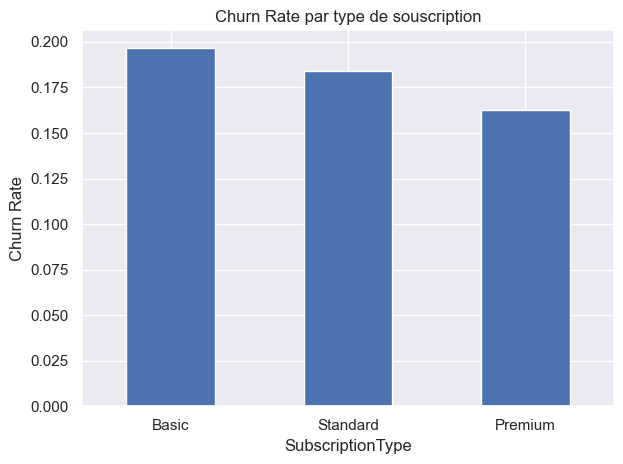

In [29]:
#Churn par type de clients
sns.set()

fig, ax = plt.subplots()


churn_par_sous = df.groupby("SubscriptionType")['Churn'].mean().sort_values(ascending = False)
print(churn_par_sous)
churn_par_sous.plot.bar(ax=ax)
plt.title('Churn Rate par type de souscription')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/churn_rate_souscription.png", dpi=300, bbox_inches='tight')
plt.show()


On constate logiquement que le maximum de désistements se fait pour les forfaits Basic à 19.65% tandis qui le minimum de désistements se fait pour les forfaits Premium à 16.3%

### Est-ce que les churners regardent moins de contenus?

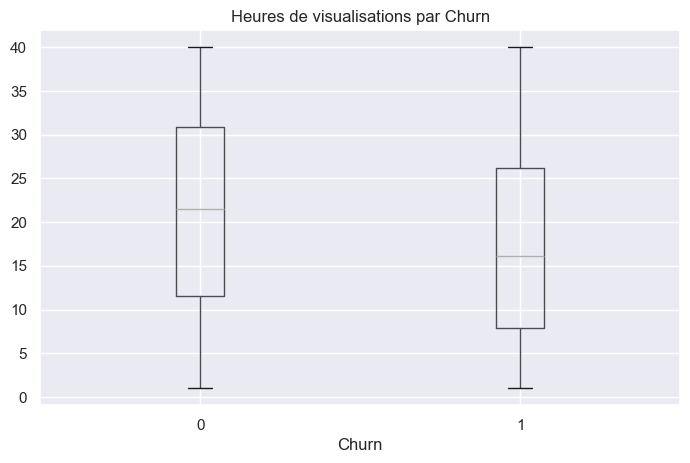

Churn
0    21.18
1    17.43
Name: ViewingHoursPerWeek, dtype: float64
La moyenne de visualisation des non churners est 21.18 heures tandis que celle des churners est 17.43 heures. 


In [31]:
df.boxplot(column='ViewingHoursPerWeek', by='Churn', figsize=(8, 5))
plt.title('Heures de visualisations par Churn')
plt.suptitle('')
plt.savefig("images/visualisation_churn.png", dpi=300, bbox_inches='tight')
plt.show()

print(df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(2))
print(f"La moyenne de visualisation des non churners est {df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(2)[0]} heures tandis que celle des churners est {df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(2)[1]} heures. ")

### Comparaison de l'âge des comptes

In [32]:
df.groupby("Churn")['AccountAge'].mean().round(2)

Churn
0    63.27
1    45.67
Name: AccountAge, dtype: float64

Les clients qui désistent ont environ 45.7 mois d'âges vs 63.3 mois pour ceux qui ne quittent pas.

### À quelle fréquence les churners ont eu besoin de soutient technique ?

In [33]:
# Support tickets
print(df.groupby('Churn')['SupportTicketsPerMonth'].mean().round(2))


Churn
0    4.39
1    5.02
Name: SupportTicketsPerMonth, dtype: float64


On constate en moyenne que les churners ont un peu plus recours au support technique que
les non churners.

### Préparation des données

In [34]:
#Retirons la colonne customerID
df = df.drop("CustomerID", axis = 1)


In [35]:
#Colonne catégorielles
col_cat = list(df.select_dtypes(include = object).columns)
col_cat

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'SubtitlesEnabled']

### Construction du modèle

In [36]:
#Séparons les variables explicatives (x) et la cible(y)
X = df.drop(["Churn"] , axis = 1)
y = df["Churn"] 


In [37]:
# Séparer en jeu d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2 , random_state = 5)

print(f"Le X_train a {X_train.shape}")
print(f"Le X_test a {X_test.shape}")

Le X_train a (195029, 19)
Le X_test a (48758, 19)


In [38]:
# Encodage des colonnes catégorielles
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[col_cat])
X_test_encoded = encoder.transform(X_test[col_cat])

#Reconstruisons un dataframe

# On obtient le nom des colonnes produits par l'encodeur
encoded_cols = encoder.get_feature_names_out(col_cat) 

#Création de datframes
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoded_cols, index=X_test.index)

#Concatenons les dataframes

X_train_final = pd.concat([X_train.drop(columns=col_cat), X_train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=col_cat), X_test_encoded], axis=1)

# Standardisons les colonnes numériques
scaler = StandardScaler()

X_train_final_scaled = scaler.fit_transform(X_train_final.drop(columns = encoded_cols))
X_test_final_scaled = scaler.transform(X_test_final.drop(columns = encoded_cols))

# Concaténons les dataframes des colonnes  numériques avec les colonne encodé à nouveau

X_train_final = pd.concat(
    [pd.DataFrame(X_train_final_scaled, columns=X_train_final.drop(columns=encoded_cols).columns,
     index=X_train.index), X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [pd.DataFrame(X_test_final_scaled, columns=X_test_final.drop(columns=encoded_cols).columns,
                  index=X_test.index),
     X_test_encoded],
    axis=1
)

### Entrainement de plusieurs modèles

Au delà de 100 000 points les modèles les plus adaptés pouraient être soient les SDGClassifier ou la régression logistique.

In [39]:
# Modèle Logistic Regression avec gestion du déséquilibre
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    solver='lbfgs'
)
# Entraînement
log_reg.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000)

In [40]:
# Modèle de SDGclassifier
sgd = SGDClassifier(
    loss="log_loss",          # régression logistique
    penalty="l2",             # régularisation standard
    alpha=0.0001,             # taux de régularisation
    class_weight="balanced",  # très important pour le churn
    early_stopping=True,      # évite le surapprentissage
    max_iter=2000,            # nombre d'itérations
    random_state=42
)
# 3. Entraînement
sgd.fit(X_train_final, y_train)

SGDClassifier(class_weight='balanced', early_stopping=True, loss='log_loss',
              max_iter=2000, random_state=42)

In [41]:
# -------------------------------
# Évaluation des modeles
# -------------------------------
def evaluate_model(model , model_name) :
    print(f"\nÉvaluation du modèle : {model_name}")

    # Prédictions sur l'ensemble d'entraînement
    y_train_pred = model.predict(X_train_final)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    print("Taux de bonne classification pour l'entraînement :", accuracy_train)

    # Prédictions sur l'ensemble de test
    y_test_pred = model.predict(X_test_final)  
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print("Taux de bonne classification pour la validation :", accuracy_test)


    # Matrice de confusion
    conf_matrix = confusion_matrix(y_test, y_test_pred)
    print("\nMatrice de confusion :\n", conf_matrix)

    # Rapport de classification
    print("\nRapport de classification :\n", classification_report(y_test, y_test_pred , target_names=['Stayed', 'Churned']))


# Évaluer tous les modèles
evaluate_model(log_reg, "Logistic Regression")
evaluate_model(sgd, "SGDClassifier")


Évaluation du modèle : Logistic Regression
Taux de bonne classification pour l'entraînement : 0.6787503396930713
Taux de bonne classification pour la validation : 0.6816727511382747

Matrice de confusion :
 [[27135 12787]
 [ 2734  6102]]

Rapport de classification :
               precision    recall  f1-score   support

      Stayed       0.91      0.68      0.78     39922
     Churned       0.32      0.69      0.44      8836

    accuracy                           0.68     48758
   macro avg       0.62      0.69      0.61     48758
weighted avg       0.80      0.68      0.72     48758


Évaluation du modèle : SGDClassifier
Taux de bonne classification pour l'entraînement : 0.6469294310076963
Taux de bonne classification pour la validation : 0.6502112473850445

Matrice de confusion :
 [[25378 14544]
 [ 2511  6325]]

Rapport de classification :
               precision    recall  f1-score   support

      Stayed       0.91      0.64      0.75     39922
     Churned       0.30      0.7

### Courbe ROC ou AUC

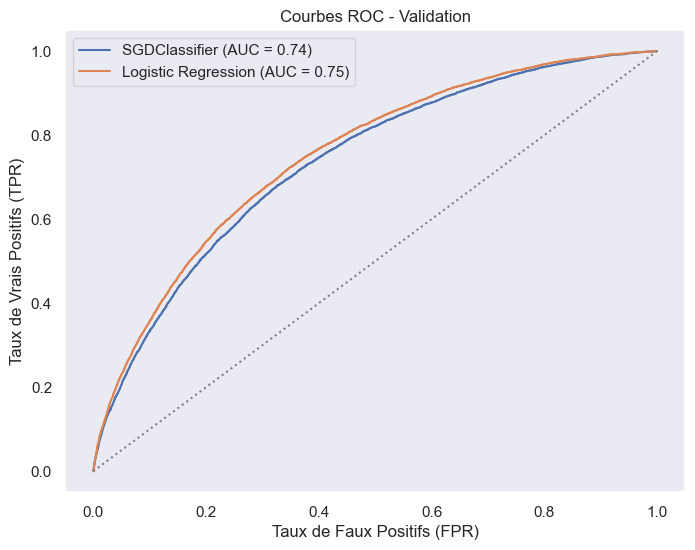

In [43]:
# Liste des modèles à évaluer
models = {
    "SGDClassifier": sgd ,
    "Logistic Regression": log_reg
}
# Initialisation du graphique
plt.figure(figsize=(8, 6))

# Tracer les courbes ROC pour chaque modèle
for name, model in models.items():
    # Prédictions des probabilités
    y_test_prob = model.predict_proba(X_test_final)[:, 1]  # Probabilité de Churn

    # Calcul des courbes ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    auc_score = auc(fpr, tpr)

    # Tracé de la courbe ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Ligne de référence (aléatoire)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')

# Labels et mise en forme
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbes ROC - Validation")
plt.legend()
plt.grid()
plt.savefig("images/courbe_ROC.png", dpi=300, bbox_inches='tight')
# Affichage
plt.show()

On choisi le modèle de régression logistique car il offre un meilleur recall de 0.69 contre 
0.66 pour le SDGClassifier.

In [44]:
# Tableau de classification
y_test_pred = log_reg.predict(X_test_final)
print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.91      0.68      0.78     39922
     Churned       0.32      0.69      0.44      8836

    accuracy                           0.68     48758
   macro avg       0.62      0.69      0.61     48758
weighted avg       0.80      0.68      0.72     48758



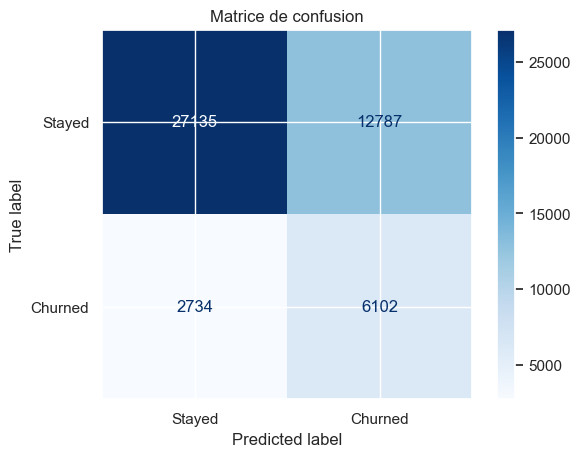

In [51]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion')
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

### Revenu à risque.

In [46]:
X_test_final

# Les probabilités pour chaque client de quitter.
y_test_prob = log_reg.predict_proba(X_test_final)[: , 1]

In [47]:
results = X_test.copy()
results['Churn_Actual'] = y_test.values
results['Churn_Probability'] = y_test_prob
results['MonthlyRevenue'] = results['MonthlyCharges']

# l'espérence du revenu mensuel à risque = probabilité de churn * revenu mensuel
results['RevenueAtRisk'] = results['Churn_Probability'] * results['MonthlyRevenue']

# On classe selon RevenueAtRisk — Le plus élevé au plus petit
results = results.sort_values('RevenueAtRisk', ascending=False)

# Total du revenu à risque
total_at_risk = results['RevenueAtRisk'].sum()
print(f"Total monthly revenue at risk: ${total_at_risk:,.0f}")

# Les 20 premier clients à contacter 
top_20 = results[['Churn_Probability', 'MonthlyRevenue', 'RevenueAtRisk']].head(20)
print(top_20)

Total monthly revenue at risk: $279,691
        Churn_Probability  MonthlyRevenue  RevenueAtRisk
77206            0.964828       19.696428      19.003663
162351           0.935865       19.942107      18.663125
167755           0.948125       19.638000      18.619288
223825           0.932664       19.916499      18.575405
164931           0.955273       19.383600      18.516639
1331             0.934759       19.808765      18.516419
161010           0.926813       19.968683      18.507238
9653             0.940069       19.617979      18.442250
231357           0.932775       19.696842      18.372726
174580           0.930865       19.728082      18.364190
82917            0.929390       19.711470      18.319641
214361           0.916985       19.974101      18.315960
87777            0.938998       19.496357      18.307039
197933           0.921768       19.817582      18.267205
13050            0.950947       19.193915      18.252403
83888            0.928355       19.628933      1

### Les features les plus importants du modèle 

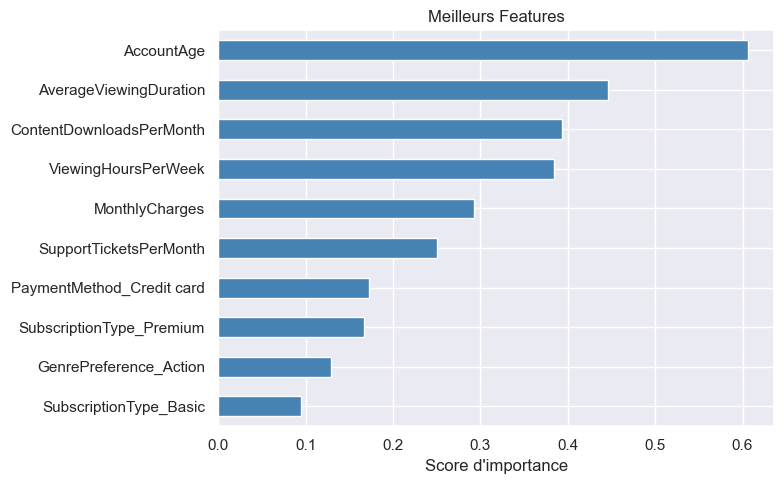

In [50]:
importances = pd.Series(log_reg.coef_[0], index=X_train_final.columns)
top_features = importances.abs().sort_values(ascending=False).head(10)

top_features.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Meilleurs Features')
plt.xlabel("Score d'importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/top_features.png", dpi=300, bbox_inches='tight')
plt.show()